In [ ]:
from tensorflow import keras
from keras.applications.vgg16 import VGG16

In [ ]:
model = VGG16()       #It have Pre-trained model

model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import load_img
from keras.applications.imagenet_utils import preprocess_input
import numpy as np

In [ ]:
image = load_img("/content/drive/MyDrive/Colab Notebooks/CNN/Train_Data/pug.jpg",target_size=(224,224))

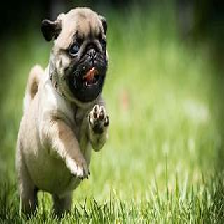

In [ ]:
image

In [ ]:
#we can't give this as input directly.so we convert this into array

image = np.array(image)

In [ ]:
image.shape

(224, 224, 3)

In [ ]:
image.shape[0]   #This will give the 0th label value of image.shape...
                 #Even if i'm changing the target size,i need not to change here again and again

224

In [ ]:
#our input_layer(InputLayer) │ (None,224,224,3) #instead of *None* we take as *1*(we need to reshape the image into this input value)

image= image.reshape(1,image.shape[0],image.shape[1],image.shape[2])   #image.reshape(1,224,224,3)

In [ ]:
image.shape

(1, 224, 224, 3)

In [ ]:
image = preprocess_input(image)

In [ ]:
image

array([[[[-103.939   , -110.779   , -123.68    ],
         [-103.939   , -110.779   , -123.68    ],
         [-103.939   , -110.779   , -123.68    ],
         ...,
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ]],

        [[-103.939   , -110.779   , -123.68    ],
         [-103.939   , -110.779   , -123.68    ],
         [-103.939   , -110.779   , -123.68    ],
         ...,
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ]],

        [[-103.939   , -109.779   , -123.68    ],
         [-103.939   , -109.779   , -123.68    ],
         [-103.939   , -109.779   , -123.68    ],
         ...,
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ],
         [-101.939   , -107.779   , -119.68    ]],

        ...,

        [[ -89.939   ,  -66.779   ,  -

In [ ]:
pred = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [ ]:
pred    #It will predict the value of 1000 classes

array([[1.96109227e-08, 1.08139355e-08, 1.17120935e-08, 5.65156633e-09,
        2.32161241e-08, 2.86403221e-08, 2.71021001e-08, 1.09839011e-05,
        2.99362309e-05, 1.51180893e-06, 1.57740442e-06, 2.20531729e-06,
        1.01227567e-06, 7.33657714e-07, 1.12034502e-06, 1.22856341e-06,
        1.78742494e-06, 2.78015832e-05, 2.91832635e-06, 7.88899627e-07,
        1.49667656e-07, 1.36513370e-06, 1.91699421e-08, 7.92221545e-05,
        4.28309941e-05, 5.72329213e-07, 3.40059678e-08, 1.45665142e-08,
        1.52523995e-07, 3.29006085e-08, 9.55475798e-07, 1.76021854e-06,
        1.93114352e-06, 4.25276340e-07, 8.59285933e-07, 2.01494095e-06,
        2.34360868e-06, 8.39389031e-06, 7.36475414e-08, 2.81165740e-06,
        5.48970888e-07, 1.28783711e-07, 1.56990282e-07, 1.42424199e-07,
        2.68029993e-07, 2.33058036e-05, 3.12637508e-06, 3.22871915e-06,
        3.85805663e-07, 3.17080094e-07, 3.49616329e-07, 4.08792431e-07,
        3.49675702e-07, 2.21132680e-07, 5.61249180e-07, 6.819092

In [ ]:
np.argmax(pred)   #but we cannot find this value coz 1000 values are there

np.int64(254)

In [ ]:
from keras.applications.vgg16 import decode_predictions

In [ ]:
output = decode_predictions(pred)     #It shows 94% as pug (prediction)
output

[[('n02110958', 'pug', np.float32(0.9488997)),
  ('n02108422', 'bull_mastiff', np.float32(0.021260638)),
  ('n02112706', 'Brabancon_griffon', np.float32(0.005512352)),
  ('n02086079', 'Pekinese', np.float32(0.0035375343)),
  ('n02108089', 'boxer', np.float32(0.0035039212))]]